In [11]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

os.getcwd()

'/home/sagemaker-user/USD-Data-Science-Cloud-Computing-Class/REAL-Glass-Project/nymeria'

In [12]:
os.listdir()

['Kamran-EDA.ipynb',
 '__init__.py',
 'body_motion_provider.py',
 'data_provider.py',
 'data_viewer.py',
 'definitions.py',
 'download_utils.py',
 'handeye.py',
 'narration_provider.py',
 'path_provider.py',
 'recording_data_provider.py',
 'sequence_attributes.py',
 'xsens_constants.py',
 '.ipynb_checkpoints']

In [13]:
os.listdir("..")

['.github',
 '.gitignore',
 'Bart Version.ipynb',
 'LICENSE',
 'Nymeria_download_urls.json',
 'README.md',
 'data',
 'download.py',
 'environment.yml',
 'nymeria',
 'setup.py',
 'temp_data',
 'viewer.py',
 '.ipynb_checkpoints']

In [14]:
os.listdir("../data")

['dataset_metadata.json', 'participants_metadata.csv']

In [15]:
for root, dirs, files in os.walk("../data"):
    print("FOLDER:", root)
    if files:
        print("FILES:", files[:10])
    print("-" * 60)

FOLDER: ../data
FILES: ['dataset_metadata.json', 'participants_metadata.csv']
------------------------------------------------------------


In [16]:
metadata_path = "../data/dataset_metadata.json"

with open(metadata_path, "r") as f:
    metadata = json.load(f)

type(metadata), list(metadata.keys())[:20]

(dict,
 ['20230607_s0_james_johnson_act0_e72nhq',
  '20230607_s0_james_johnson_act1_7xwm28',
  '20230607_s0_james_johnson_act2_yhbvpa',
  '20230607_s0_james_johnson_act3_ifj2gc',
  '20230607_s1_barbara_wheeler_act0_cvxtsi',
  '20230607_s1_barbara_wheeler_act1_nkg6zo',
  '20230607_s1_barbara_wheeler_act2_ig1oym',
  '20230607_s1_barbara_wheeler_act3_qx6buy',
  '20230607_s1_barbara_wheeler_act4_5adv12',
  '20230608_s0_shelby_arroyo_act0_3ciwl8',
  '20230608_s0_shelby_arroyo_act1_w436lf',
  '20230608_s0_shelby_arroyo_act3_h8gcy2',
  '20230609_s0_angela_harrell_act2_42epvf',
  '20230609_s0_angela_harrell_act3_rk26s0',
  '20230609_s0_angela_harrell_act4_egucf6',
  '20230609_s1_heather_becker_act0_pxfo7n',
  '20230609_s1_heather_becker_act1_jkyybw',
  '20230609_s1_heather_becker_act2_2e7xi1',
  '20230609_s1_heather_becker_act3_8le2tb',
  '20230612_s0_jason_smith_act0_perjr7'])

In [17]:
for key, value in metadata.items():
    print(f"\nKEY: {key}")
    print(f"TYPE: {type(value)}")
    if isinstance(value, list):
        print(f"LENGTH: {len(value)}")
        print("FIRST ITEM:", value[0] if len(value) > 0 else "Empty")
    elif isinstance(value, dict):
        print(f"DICT KEYS: {list(value.keys())[:10]}")
    else:
        print(value)


KEY: 20230607_s0_james_johnson_act0_e72nhq
TYPE: <class 'dict'>
DICT KEYS: ['device_serial', 'duration_s', 'sensor.slam_camera_fps', 'sensor.rgb_camera_fps', 'sensor.et_camera_fps', 'sensor.rgb_image_height', 'sensor.rgb_image_width', 'computed.light_intensity_lux_median', 'computed.trajectory_length_m', 'computed.covered_area_m2']

KEY: 20230607_s0_james_johnson_act1_7xwm28
TYPE: <class 'dict'>
DICT KEYS: ['license', 'version', 'date', 'session_id', 'fake_name', 'act_id', 'uid', 'location', 'script', 'action_duration_sec']

KEY: 20230607_s0_james_johnson_act2_yhbvpa
TYPE: <class 'dict'>
DICT KEYS: ['device_serial', 'duration_s', 'sensor.slam_camera_fps', 'sensor.rgb_camera_fps', 'sensor.et_camera_fps', 'sensor.rgb_image_height', 'sensor.rgb_image_width', 'computed.light_intensity_lux_median', 'computed.trajectory_length_m', 'computed.covered_area_m2']

KEY: 20230607_s0_james_johnson_act3_ifj2gc
TYPE: <class 'dict'>
DICT KEYS: ['device_serial', 'duration_s', 'sensor.slam_camera_fps', 

In [18]:
df_meta = pd.DataFrame.from_dict(metadata, orient="index")

df_meta.head()

,device_serial,duration_s,sensor.slam_camera_fps,sensor.rgb_camera_fps,sensor.et_camera_fps,sensor.rgb_image_height,sensor.rgb_image_width,computed.light_intensity_lux_median,computed.trajectory_length_m,computed.covered_area_m2,computed.covered_volume_m3,computed.speed_mps_mean,license,version,date,session_id,fake_name,act_id,uid,location,script,action_duration_sec,has_two_participants,pt2,body_motion,head_data,head_slam,head_trajectory_m,head_duration_sec,head_general_gaze,head_personalized_gaze,left_wrist_data,left_wrist_slam,left_wrist_trajectory_m,left_wrist_duration_sec,right_wrist_data,right_wrist_slam,right_wrist_trajectory_m,right_wrist_duration_sec,observer_data,observer_slam,observer_general_gaze,observer_personalized_gaze,observer_trajectory_m,observer_duration_sec,timesync,motion_narration,atomic_action,activity_summarization,participant_gender,participant_height_cm,participant_weight_kg,participant_bmi,participant_age_group,participant_ethnicity,participant_xsens_suit_size
20230607_s0_james_johnson_act0_e72nhq,1WM093701G1263,1220.64,15.0,15.0,30.0,1408.0,1408.0,282.05,234.48,339.82,1040.01,0.19,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act0,e72nhq,Loc_04,S14-By_my_desk,824.135,False,None,True,True,True,234.43,1220.604765,True,True,True,True,275.17,845.150087,True,True,286.03,844.50,True,True,True,True,208.90,930.451197,True,False,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M
20230607_s0_james_johnson_act2_yhbvpa,1WM093701G1263,988.13,15.0,15.0,30.0,1408.0,1408.0,188.20,185.69,63.81,70.86,0.19,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act2,yhbvpa,Loc_04,S19-Fresh_air,859.660,False,None,True,True,True,185.47,988.040000,True,False,True,True,214.44,887.700000,True,True,218.09,884.45,True,True,True,True,123.10,1003.840000,True,False,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M
20230607_s0_james_johnson_act3_ifj2gc,1WM093701G1263,949.05,15.0,15.0,30.0,1408.0,1408.0,286.46,70.44,2.40,1.97,0.07,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act3,ifj2gc,Loc_04,S12-Game_night,824.670,False,None,True,True,True,70.34,948.910000,True,True,True,True,88.02,835.550000,True,True,144.59,831.95,True,True,True,True,93.51,973.710000,True,False,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M
20230607_s1_barbara_wheeler_act0_cvxtsi,1WM093701G1263,1161.35,15.0,15.0,30.0,1408.0,1408.0,482.2,133.84,47.06,47.15,0.12,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act0,cvxtsi,Loc_04,S14-By_my_desk,973.380,False,None,True,True,True,133.72,1161.280000,True,True,True,True,123.92,1027.150000,True,True,178.58,1029.25,True,True,True,True,78.71,1114.690000,True,False,True,True,Male,195.0,96.0,25.2,18-24,African American,XXL
20230607_s1_barbara_wheeler_act1_nkg6zo,1WM093701G1263,1001.04,15.0,15.0,30.0,1408.0,1408.0,498.11,97.09,4.3,4.34,0.1,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act1,nkg6zo,Loc_04,S1-Relax_at_home,895.390,False,None,True,True,True,97.01,1000.970000,True,True,True,True,92.88,934.750000,True,True,110.84,933.00,True,True,True,True,30.31,990.110000,True,False,True,True,Male,195.0,96.0,25.2,18-24,African American,XXL


In [19]:
df_meta = df_meta.reset_index()
df_meta = df_meta.rename(columns={"index": "recording_id"})

df_meta.head()

,recording_id,device_serial,duration_s,sensor.slam_camera_fps,sensor.rgb_camera_fps,sensor.et_camera_fps,sensor.rgb_image_height,sensor.rgb_image_width,computed.light_intensity_lux_median,computed.trajectory_length_m,computed.covered_area_m2,computed.covered_volume_m3,computed.speed_mps_mean,license,version,date,session_id,fake_name,act_id,uid,location,script,action_duration_sec,has_two_participants,pt2,body_motion,head_data,head_slam,head_trajectory_m,head_duration_sec,head_general_gaze,head_personalized_gaze,left_wrist_data,left_wrist_slam,left_wrist_trajectory_m,left_wrist_duration_sec,right_wrist_data,right_wrist_slam,right_wrist_trajectory_m,right_wrist_duration_sec,observer_data,observer_slam,observer_general_gaze,observer_personalized_gaze,observer_trajectory_m,observer_duration_sec,timesync,motion_narration,atomic_action,activity_summarization,participant_gender,participant_height_cm,participant_weight_kg,participant_bmi,participant_age_group,participant_ethnicity,participant_xsens_suit_size
0,20230607_s0_james_johnson_act0_e72nhq,1WM093701G1263,1220.64,15.0,15.0,30.0,1408.0,1408.0,282.05,234.48,339.82,1040.01,0.19,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act0,e72nhq,Loc_04,S14-By_my_desk,824.135,False,None,True,True,True,234.43,1220.604765,True,True,True,True,275.17,845.150087,True,True,286.03,844.50,True,True,True,True,208.90,930.451197,True,False,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M
1,20230607_s0_james_johnson_act2_yhbvpa,1WM093701G1263,988.13,15.0,15.0,30.0,1408.0,1408.0,188.20,185.69,63.81,70.86,0.19,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act2,yhbvpa,Loc_04,S19-Fresh_air,859.660,False,None,True,True,True,185.47,988.040000,True,False,True,True,214.44,887.700000,True,True,218.09,884.45,True,True,True,True,123.10,1003.840000,True,False,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M
2,20230607_s0_james_johnson_act3_ifj2gc,1WM093701G1263,949.05,15.0,15.0,30.0,1408.0,1408.0,286.46,70.44,2.40,1.97,0.07,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act3,ifj2gc,Loc_04,S12-Game_night,824.670,False,None,True,True,True,70.34,948.910000,True,True,True,True,88.02,835.550000,True,True,144.59,831.95,True,True,True,True,93.51,973.710000,True,False,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M
3,20230607_s1_barbara_wheeler_act0_cvxtsi,1WM093701G1263,1161.35,15.0,15.0,30.0,1408.0,1408.0,482.2,133.84,47.06,47.15,0.12,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act0,cvxtsi,Loc_04,S14-By_my_desk,973.380,False,None,True,True,True,133.72,1161.280000,True,True,True,True,123.92,1027.150000,True,True,178.58,1029.25,True,True,True,True,78.71,1114.690000,True,False,True,True,Male,195.0,96.0,25.2,18-24,African American,XXL
4,20230607_s1_barbara_wheeler_act1_nkg6zo,1WM093701G1263,1001.04,15.0,15.0,30.0,1408.0,1408.0,498.11,97.09,4.3,4.34,0.1,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act1,nkg6zo,Loc_04,S1-Relax_at_home,895.390,False,None,True,True,True,97.01,1000.970000,True,True,True,True,92.88,934.750000,True,True,110.84,933.00,True,True,True,True,30.31,990.110000,True,False,True,True,Male,195.0,96.0,25.2,18-24,African American,XXL


In [20]:
print("Shape:", df_meta.shape)
df_meta.info()

Shape: (1100, 57)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 57 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   recording_id                         1100 non-null   object 
 1   device_serial                        1016 non-null   object 
 2   duration_s                           1016 non-null   object 
 3   sensor.slam_camera_fps               1016 non-null   float64
 4   sensor.rgb_camera_fps                1016 non-null   float64
 5   sensor.et_camera_fps                 1016 non-null   float64
 6   sensor.rgb_image_height              1016 non-null   float64
 7   sensor.rgb_image_width               1016 non-null   float64
 8   computed.light_intensity_lux_median  1016 non-null   object 
 9   computed.trajectory_length_m         1016 non-null   object 
 10  computed.covered_area_m2             1016 non-null   object 
 11  computed.cov

The dataset metadata was converted into a tabular format where each recording corresponds to a row and metadata attributes correspond to columns. This allows standard exploratory analysis techniques to be applied.

In [21]:
numeric_convert_cols = [
    "duration_s",
    "computed.light_intensity_lux_median",
    "computed.trajectory_length_m",
    "computed.covered_area_m2",
    "computed.covered_volume_m3",
    "computed.speed_mps_mean"
]

for col in numeric_convert_cols:
    df_meta[col] = pd.to_numeric(df_meta[col], errors="coerce")

df_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 57 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   recording_id                         1100 non-null   object 
 1   device_serial                        1016 non-null   object 
 2   duration_s                           1016 non-null   float64
 3   sensor.slam_camera_fps               1016 non-null   float64
 4   sensor.rgb_camera_fps                1016 non-null   float64
 5   sensor.et_camera_fps                 1016 non-null   float64
 6   sensor.rgb_image_height              1016 non-null   float64
 7   sensor.rgb_image_width               1016 non-null   float64
 8   computed.light_intensity_lux_median  1016 non-null   float64
 9   computed.trajectory_length_m         1016 non-null   float64
 10  computed.covered_area_m2             1016 non-null   float64
 11  computed.covered_volume_m3    

Several metadata fields that represent numeric measurements were initially stored as object data types. These fields were converted to numeric values using pandas.to_numeric() to enable statistical analysis and visualization.

In [22]:
missing_counts = df_meta.isnull().sum().sort_values(ascending=False)

missing_counts[missing_counts > 0]

pt2                                    883
sensor.et_camera_fps                    84
duration_s                              84
sensor.slam_camera_fps                  84
sensor.rgb_camera_fps                   84
sensor.rgb_image_width                  84
sensor.rgb_image_height                 84
computed.light_intensity_lux_median     84
device_serial                           84
computed.speed_mps_mean                 84
computed.trajectory_length_m            84
computed.covered_volume_m3              84
computed.covered_area_m2                84
observer_trajectory_m                    3
observer_duration_sec                    3
right_wrist_duration_sec                 2
right_wrist_trajectory_m                 2
left_wrist_trajectory_m                  1
left_wrist_duration_sec                  1
dtype: int64

In [23]:
missing_percent = (df_meta.isnull().sum() / len(df_meta)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": df_meta.isnull().sum(),
    "Missing Percent": missing_percent
}).sort_values(by="Missing Percent", ascending=False)

missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing Percent
pt2,883,80.272727
sensor.et_camera_fps,84,7.636364
duration_s,84,7.636364
sensor.slam_camera_fps,84,7.636364
sensor.rgb_camera_fps,84,7.636364
sensor.rgb_image_width,84,7.636364
sensor.rgb_image_height,84,7.636364
computed.light_intensity_lux_median,84,7.636364
device_serial,84,7.636364
computed.speed_mps_mean,84,7.636364


The column pt2 contains approximately 80% missing values. This likely reflects recordings involving only a single participant, as the dataset also contains a has_two_participants indicator variable. Therefore, these missing values are expected and do not necessarily represent data quality issues.

Approximately 7.6% of recordings contain missing values in several sensor-derived fields such as trajectory length, movement speed, and camera frame rates. Because these fields share the same missing count, it is likely that these recordings lack the corresponding sensor data or failed during the preprocessing pipeline.

A small number of recordings contain missing values in wrist and observer motion attributes. These represent less than 0.3% of the dataset and are unlikely to significantly impact analysis.

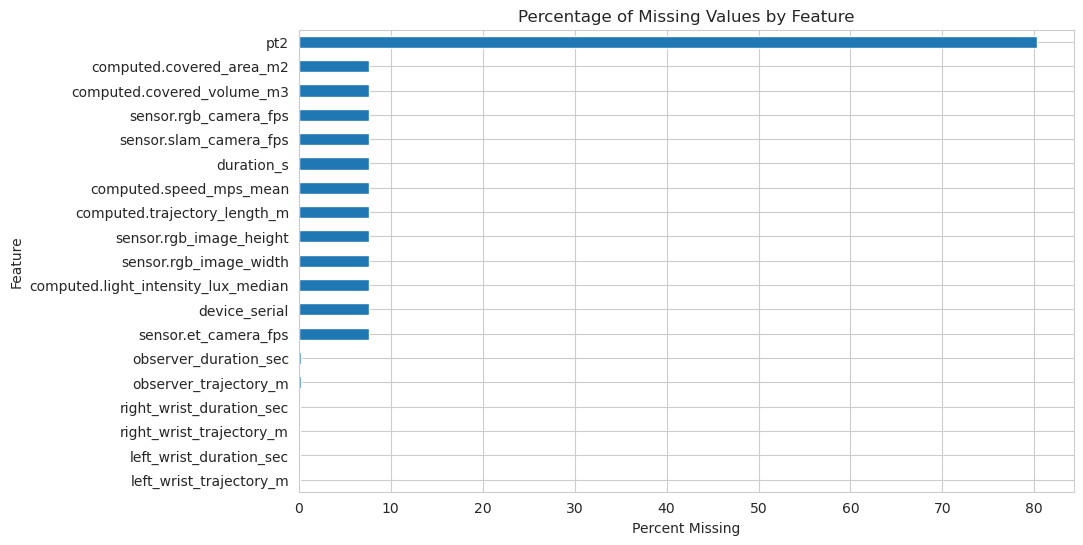

In [24]:
plt.figure(figsize=(10,6))

missing_percent[missing_percent > 0].sort_values().plot(
    kind="barh"
)

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Percent Missing")
plt.ylabel("Feature")

plt.show()

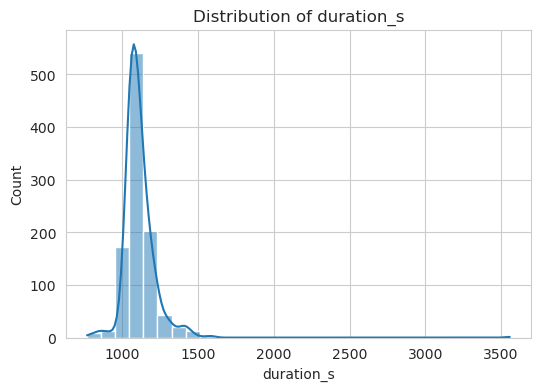

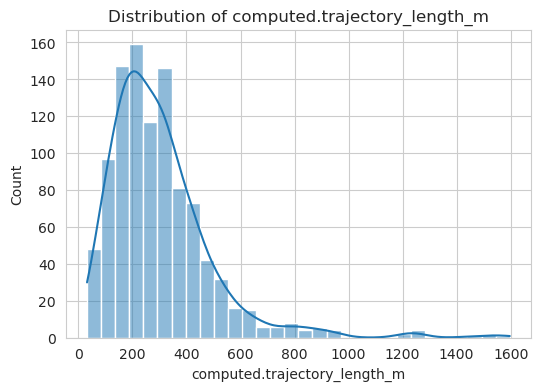

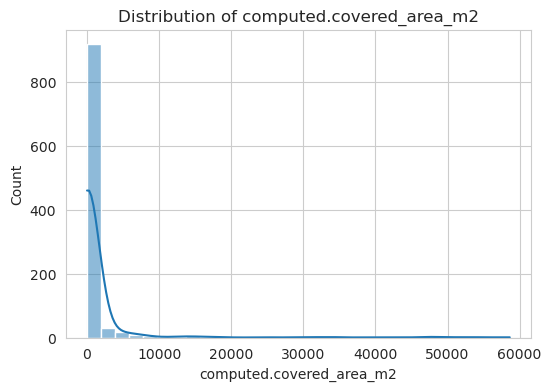

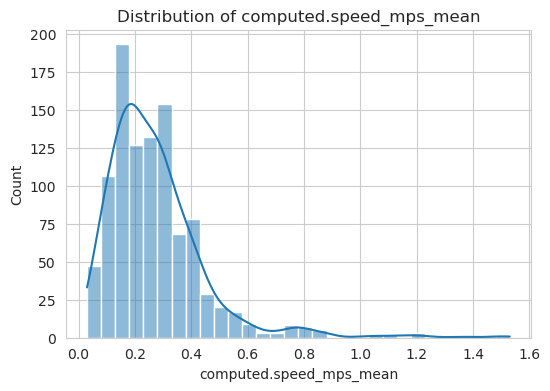

In [25]:
movement_cols = [
    "duration_s",
    "computed.trajectory_length_m",
    "computed.covered_area_m2",
    "computed.speed_mps_mean"
]

for col in movement_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_meta[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

The movement-related variables in the dataset exhibit right-skewed distributions, indicating that while most activities involve moderate movement, a smaller number of recordings involve substantially larger spatial coverage or movement speeds. Recording duration appears relatively consistent across sessions, suggesting that the dataset was collected under a standardized recording protocol. These movement characteristics provide useful insight into participant behavior during recorded activities and may serve as important features in downstream modeling tasks.

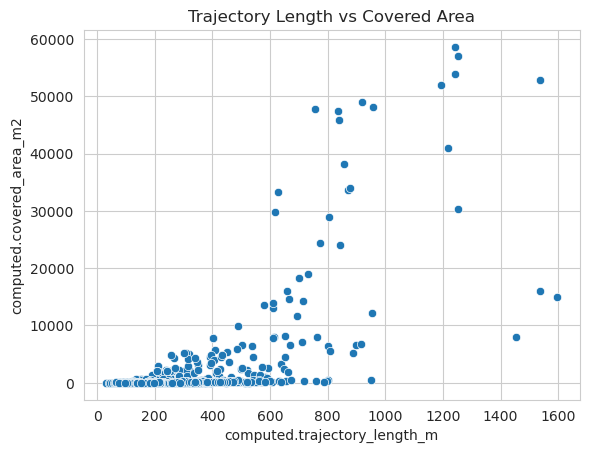

In [26]:
sns.scatterplot(
    x="computed.trajectory_length_m",
    y="computed.covered_area_m2",
    data=df_meta
)

plt.title("Trajectory Length vs Covered Area")
plt.show()

As expected, trajectory length is positively associated with covered spatial area, since recordings with longer movement paths tend to span larger physical spaces.

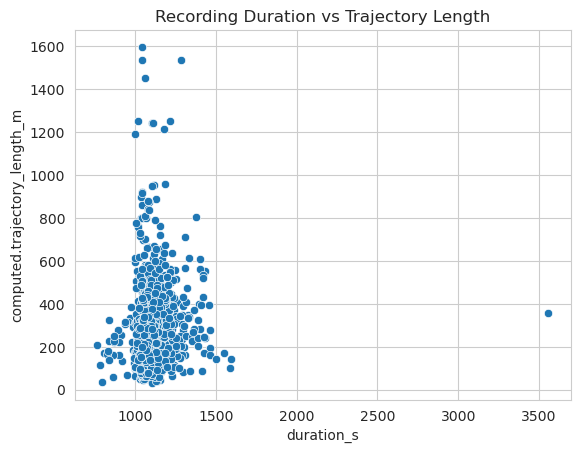

In [27]:
sns.scatterplot(
    x="duration_s",
    y="computed.trajectory_length_m",
    data=df_meta
)

plt.title("Recording Duration vs Trajectory Length")
plt.show()

The relationship between recording duration and trajectory length appears weakly correlated, with most recordings clustered within a consistent duration range but varying in movement distance. This suggests that longer recordings do not necessarily involve greater movement, indicating differences in activity intensity. Additionally, several outliers exhibit unusually high movement distances or recording durations, which may represent unique activities or anomalies in the dataset.

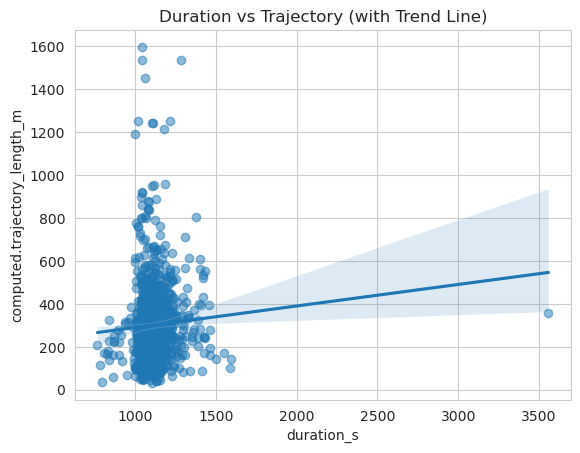

In [28]:
sns.regplot(
    x="duration_s",
    y="computed.trajectory_length_m",
    data=df_meta,
    scatter_kws={"alpha":0.5}
)

plt.title("Duration vs Trajectory (with Trend Line)")
plt.show()

In [29]:
df_meta["duration_s"].corr(df_meta["computed.trajectory_length_m"])

0.06323300136913419

The correlation between recording duration and trajectory length is relatively low, confirming that duration alone is not a strong predictor of movement distance.

In [30]:
df_meta["movement_intensity"] = (
    df_meta["computed.trajectory_length_m"] /
    df_meta["duration_s"]
)

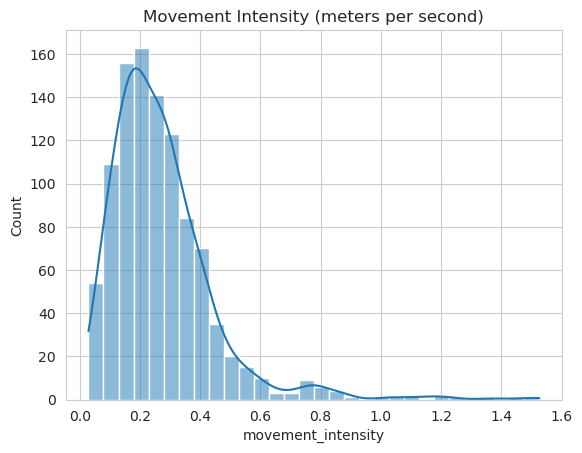

In [31]:
sns.histplot(df_meta["movement_intensity"], bins=30, kde=True)
plt.title("Movement Intensity (meters per second)")
plt.show()

A derived feature representing movement intensity was created by normalizing trajectory length by recording duration. This metric provides a more meaningful representation of activity level across recordings.

In [33]:
df_meta["intensity_level"] = pd.qcut(
    df_meta["movement_intensity"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

df_meta["intensity_level"].value_counts()

intensity_level
Low          254
Medium       254
High         254
Very High    254
Name: count, dtype: int64

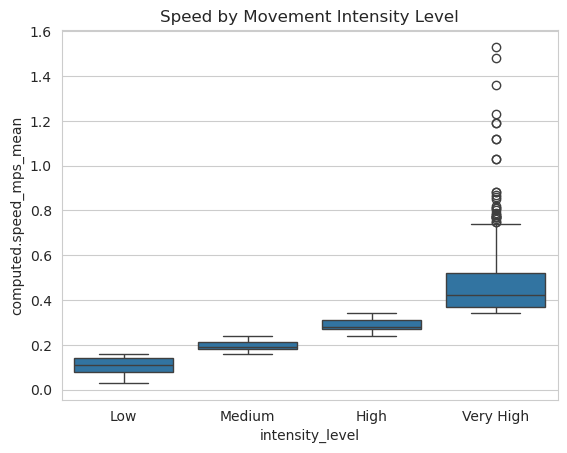

In [34]:
sns.boxplot(
    x="intensity_level",
    y="computed.speed_mps_mean",
    data=df_meta
)

plt.title("Speed by Movement Intensity Level")
plt.show()

The relationship between movement intensity and average speed shows a clear increasing trend across intensity levels. Recordings classified as “Very High” intensity exhibit significantly higher speeds compared to lower categories. This confirms that the derived movement intensity feature effectively captures differences in activity levels. Additionally, the higher variability in the “Very High” category suggests a wider range of movement behaviors in more dynamic recordings.

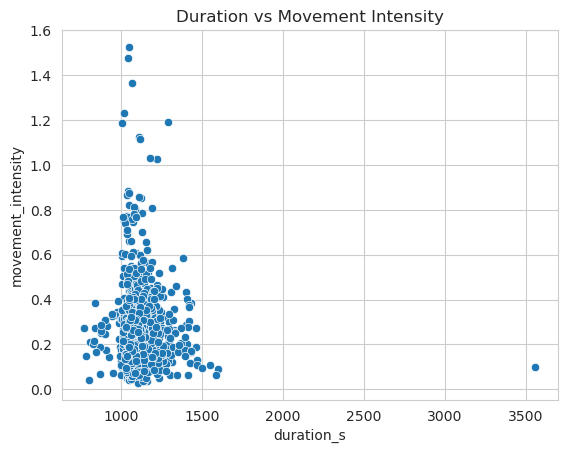

In [35]:
sns.scatterplot(
    x="duration_s",
    y="movement_intensity",
    data=df_meta
)

plt.title("Duration vs Movement Intensity")
plt.show()

The relationship between recording duration and movement intensity shows no clear correlation. Recordings with similar durations exhibit a wide range of intensity values, indicating that activity level is not determined by recording length. This suggests that movement intensity captures behavioral differences more effectively than duration alone. Additionally, some outliers highlight recordings with unusually high or low intensity relative to their duration.

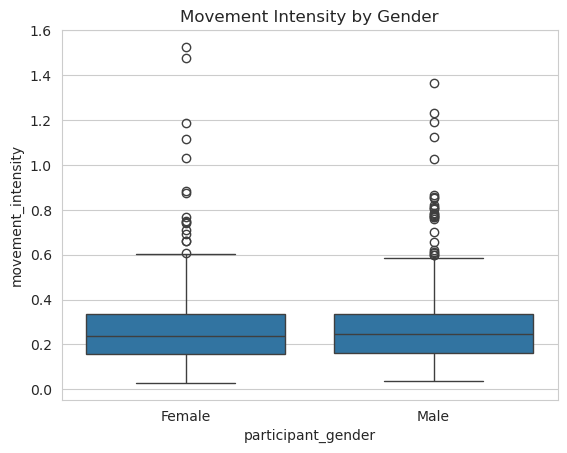

In [36]:
sns.boxplot(
    x="participant_gender",
    y="movement_intensity",
    data=df_meta
)

plt.title("Movement Intensity by Gender")
plt.show()